# Custom residual CNN versus transfer learning for age and binary gender-label prediction

This project asks whether ImageNet transfer learning helps when a multi-task face model has only 5,000 task-specific training images.

I compare a purpose-built residual CNN with an ImageNet-pretrained ResNet50V2 on the same age-regression and binary-label task. On the recorded evaluation, Model A achieved an age MAE of **6.5747 years** and binary gender-label accuracy of **0.9010**. Model B recorded **7.2968 years** and **0.8890**. These results describe this split, training run and checkpoint policy; they do not establish that one architecture always wins.

## Project question

I wanted to test whether a pretrained visual feature extractor would improve both tasks when the target dataset was relatively small. My expectation was that transfer learning would help. In this experiment it did not: the custom model produced the stronger selected validation result under the same split and evaluation policy.

That counter-result is useful. It gives the comparison a clear outcome to investigate rather than assuming that a larger pretrained network must be better.

### Implementation map

The main design choices can be traced directly to these package modules:

| Concern | Source entry points |
| --- | --- |
| Labels, split, loading and augmentation | [`data.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/data.py) |
| Model A, Model B and fine-tuning | [`models.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/models.py) |
| Losses, phases and checkpoint selection | [`training.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/training.py) |
| Face crop, model cache and prediction | [`inference.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/inference.py) |

The plotting functions in [`plots.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/plots.py) are kept separate from the model and training code.

In [1]:
RUN_TRAINING_PIPELINE = False
DATA_DIR = None
MODEL_CACHE_DIR = None
TRAINING_OUTPUT_DIR = None

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").is_file() and (ROOT.parent / "pyproject.toml").is_file():
    ROOT = ROOT.parent
SOURCE_DIR = ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

print(f"Project root: {ROOT.name}")

Project root: portfolio-build


## Data and multi-task formulation

I used a 5,000-image subset of UTKFace (Zhang, Song and Qi, 2017). The filename supplies the age and binary dataset label. `data.py` checks those fields, converts OpenCV's BGR output to RGB, resizes each image to 128 × 128 and scales the pixels to [0, 1]. A seeded shuffle gives both models the same 80/20 training-validation split.

For input image `$x_i$`, a shared trunk `$h_i=f(x_i)$` feeds two heads:

\[
\hat y_i^{(age)} = f_{age}(h_i),
\qquad
\hat y_i^{(label)} = \sigma\!\left(f_{label}(h_i)\right).
\]

This lets the two tasks learn from a common representation while retaining separate final layers, as proposed by Caruana (1997). The sigmoid output follows the dataset's binary-label convention. It should not be interpreted as a person's gender identity.

### Conservative augmentation

Both model builders call the same `build_augmentation_layers` function. It applies horizontal flips, rotations up to 3% of a turn, zoom up to 5% and translations up to 5% of the image dimensions. These small changes represent ordinary variation in how a face is captured, as discussed by Shorten and Khoshgoftaar (2019).

The grid uses [Simu Liu on The Beaverton](https://commons.wikimedia.org/wiki/File:Simu_Liu_on_The_Beaverton.jpg) under [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/). I crop the face tightly so the transforms are easy to see; the following cell runs the same augmenter used by the models on this one image.

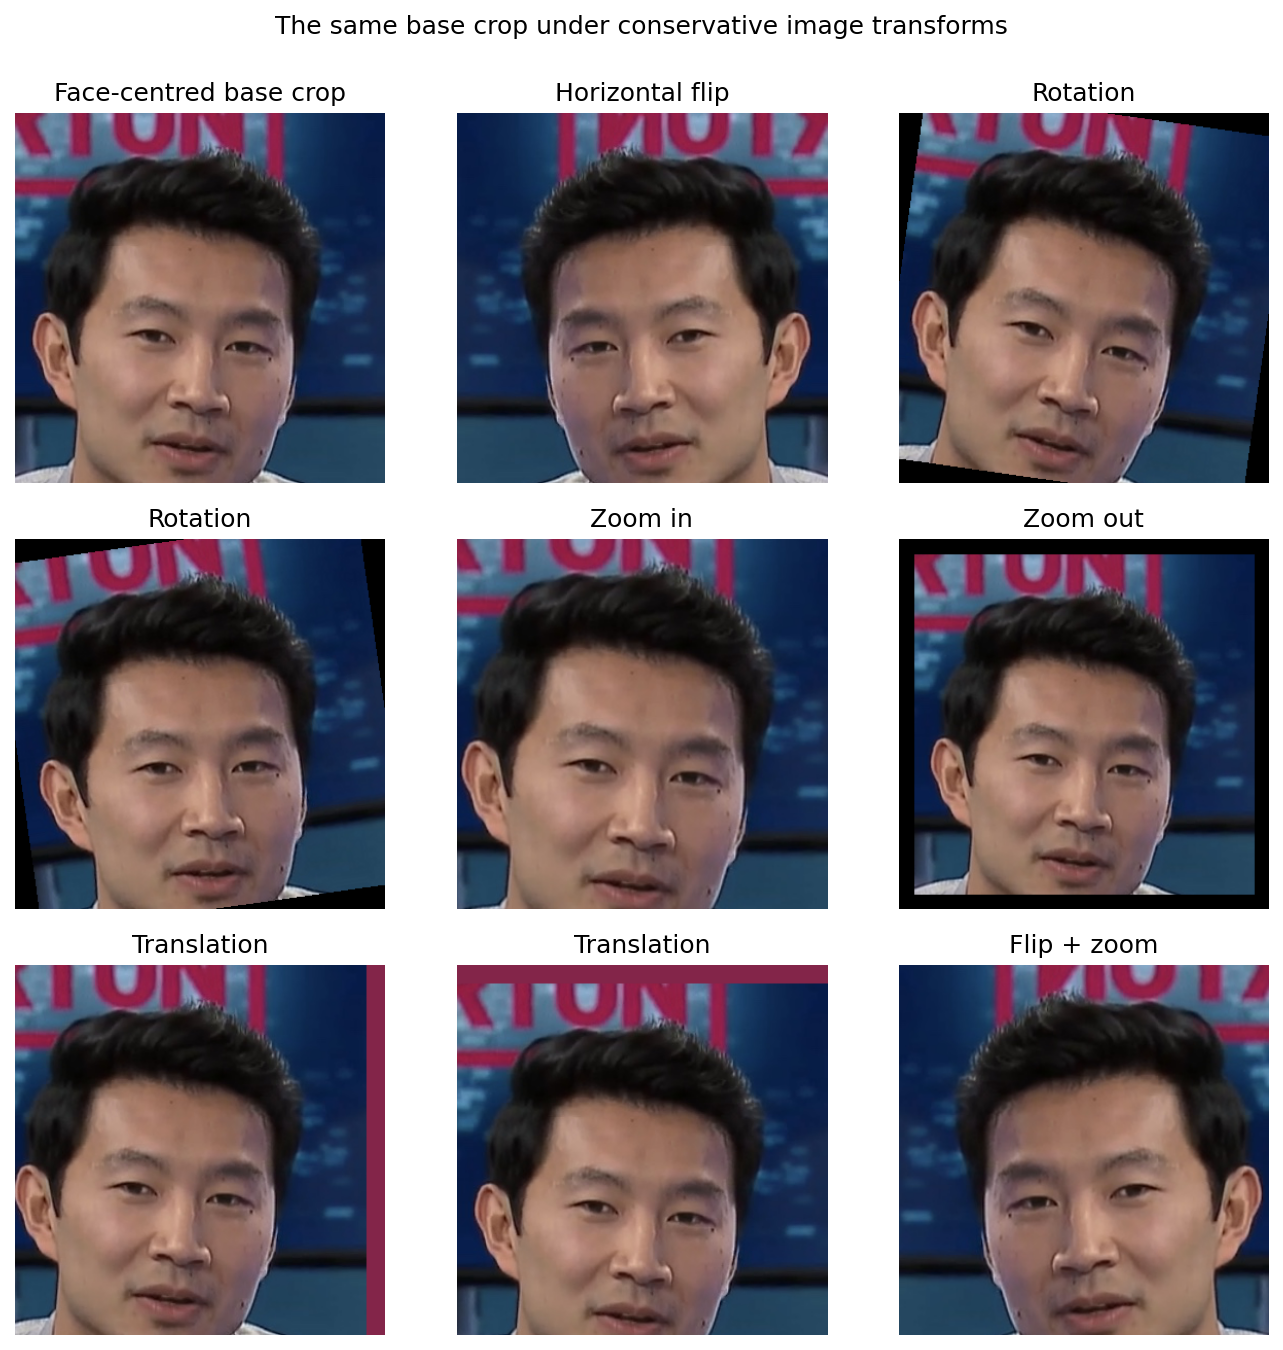

In [1]:
from IPython.display import Image, display
import numpy as np
from PIL import Image as PILImage

example_path = ROOT / "assets/examples/simu-liu-beaverton.jpg"
with PILImage.open(example_path) as source:
    public_rgb = np.asarray(source.convert("RGB"), dtype=np.float32) / 255.0

# Fixed for presentation only: the training images are not changed here.
face_centred_base = public_rgb[60:420, 560:920]

try:
    import keras
    from age_gender_cnn.data import build_augmentation_layers
except ImportError:
    # Reference mode remains usable without the optional TensorFlow/Keras install.
    display(Image(filename=str(ROOT / "artifacts/reference/augmentation-example.png")))
else:
    import matplotlib.pyplot as plt
    from age_gender_cnn.plots import plot_augmentation_grid

    keras.utils.set_random_seed(7)
    augmenter = build_augmentation_layers(keras)

    def augment_once(image):
        """Apply the same Keras layer used inside both model builders."""
        return augmenter(image[None, ...], training=True).numpy()[0]

    augmentation_figure = plot_augmentation_grid(
        face_centred_base,
        augment=augment_once,
        base_title="Face-centred base crop",
    )
    display(augmentation_figure)
    plt.close(augmentation_figure)


## Model A: a task-specific residual CNN

This is the main architectural contribution of the project. I used TensorFlow/Keras built-in layers to build a residual CNN rather than a conventional stack of independent convolutional layers. The residual design also makes Model A a closer comparison with Model B, since both feature extractors use shortcut connections; the important difference is that Model A learns its features from scratch while Model B starts from ImageNet weights. The design follows the residual-learning idea introduced by He et al. (2016).

A residual connection lets a block learn a transformation `$F(x)$` and add it to a shortcut `$S(x)$`:

\[
y=\phi\!\left(F(x)+S(x)\right).
\]

In the first block, `$S(x)=x$` because the channel count stays at 32. In the next two blocks, a 1 × 1 convolution projects the shortcut from 32 to 64 channels and then from 64 to 128. Each block is followed by dropout and max pooling, reducing the spatial feature map to 8 × 8 × 128 before the shared dense layer. This is why the first fully connected layer receives a compact representation without discarding the learned shortcut path.

The implementation is in [`models.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/models.py); the loss policy is defined in [`training.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/training.py):

\[
\mathcal{L}=3.0\,\mathcal{L}_{label}+0.30\,\mathcal{L}_{age},
\qquad
\mathcal{L}_{age}=\operatorname{Huber}_{\delta=6.5}(y-\hat y).
\]

Binary cross-entropy trains the label head. I selected the Huber delta of 6.5 empirically during the initial experiments, based on the observed validation behaviour rather than a value prescribed by the loss definition. The explicit task weights prevent one raw loss from dominating simply because it is measured on a different scale. Model A contains **2,440,834 parameters**, of which **2,438,978** are trainable before optimisation.

## Model B: ResNet50V2 transfer learning

I chose ResNet50V2 because it gives the comparison a meaningful baseline. Model A already uses residual learning, so comparing it with a pretrained ResNet keeps the broad feature-extractor design similar while changing the source of the weights and the model scale. ResNet50V2 removes the original ImageNet classifier (`include_top=False`), applies global average pooling and then uses the same shared dense layer and two task heads as Model A. Features that work well for ImageNet are not guaranteed to transfer to a smaller apparent-age and binary-label task, as discussed by Yosinski et al. (2014).

In transfer learning, **backbone** is the standard term for the pretrained convolutional feature extractor before the new task-specific layers. I froze this backbone for the first phase so that the randomly initialised heads could learn the age and label tasks without immediately changing all of the ImageNet features. This also reduced the number of trainable parameters and limited overfitting on the 5,000-image target dataset.

After the frozen phase, [`set_model_b_fine_tuning`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/models.py) unfreezes only the final 30 backbone layers. [`train_model_b`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/training.py) recompiles at learning rate 10⁻⁵ and keeps Batch Normalisation layers fixed, avoiding a sudden change to pretrained statistics. The model contains **24,123,394 parameters**; **558,082** are trainable in the frozen phase and **14,984,194** in fine-tuning.

### Architecture at a glance

The comparison is deliberately close. Model A is not a plain CNN: it uses residual blocks trained from scratch. Model B uses the established ResNet50V2 residual architecture with ImageNet initialisation. Both models take the same input, use the same augmentation and end in the same two prediction heads.

<table>
<caption>Architecture and training differences</caption>
<thead><tr><th>Stage</th><th>Model A: custom residual CNN</th><th>Model B: ResNet50V2 transfer</th></tr></thead>
<tbody>
<tr><td>Input</td><td>128 × 128 × 3, scaled to [0, 1]</td><td>128 × 128 × 3, scaled to [0, 1] then [-1, 1]</td></tr>
<tr><td>Feature extractor</td><td>32-filter stem; residual blocks with 32, 64 and 128 filters</td><td>ImageNet-pretrained ResNet50V2, without its classification top</td></tr>
<tr><td>Shared representation</td><td>8 × 8 × 128 feature map, flattening, then Dense(256)</td><td>Global average pooling, then Dense(256)</td></tr>
<tr><td>Prediction heads</td><td colspan="2">Separate 64-unit branches; sigmoid binary-label output and linear age output</td></tr>
<tr><td>Training</td><td>All layers trained from scratch</td><td>Backbone frozen first; final 30 layers then fine-tuned at 10⁻⁵</td></tr>
<tr><td>Parameters</td><td>2,440,834 total</td><td>24,123,394 total</td></tr>
</tbody>
</table>

## What the validation comparison showed

The results below are the fixed reference comparison for this project. I keep the metrics and curve images in `artifacts/reference/` so that rerunning the optional training cell cannot quietly replace the recorded result.

Age error is reported as mean absolute error:

\[
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}\lvert y_i-\hat y_i\rvert.
\]

In the Model B curves, the dashed vertical line marks the change from frozen-base training to fine-tuning. `plot_selected_metrics` creates the table and `plot_reference_curves` creates the curve panels; both functions are in [`plots.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/plots.py).

| Model | Age MAE (years) | Binary gender-label accuracy | Combined loss |
|---|---:|---:|---:|
| Model A — custom residual | 6.5747 | 0.9010 | 2.8543 |
| Model B — ResNet50V2 | 7.2968 | 0.8890 | 2.9620 |

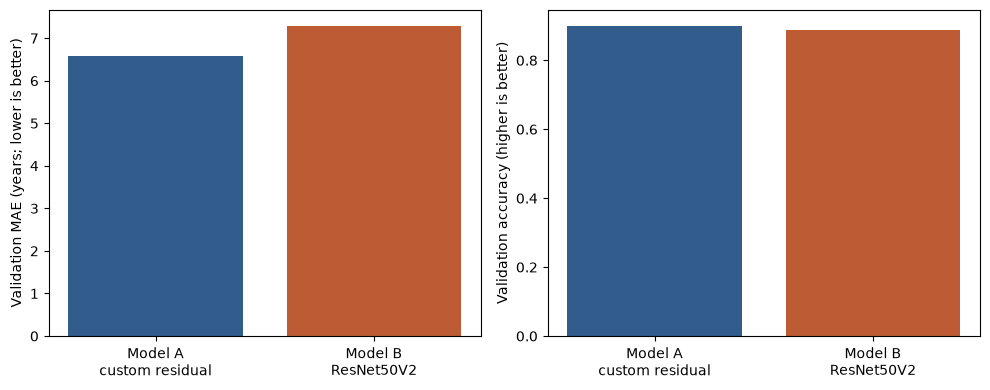

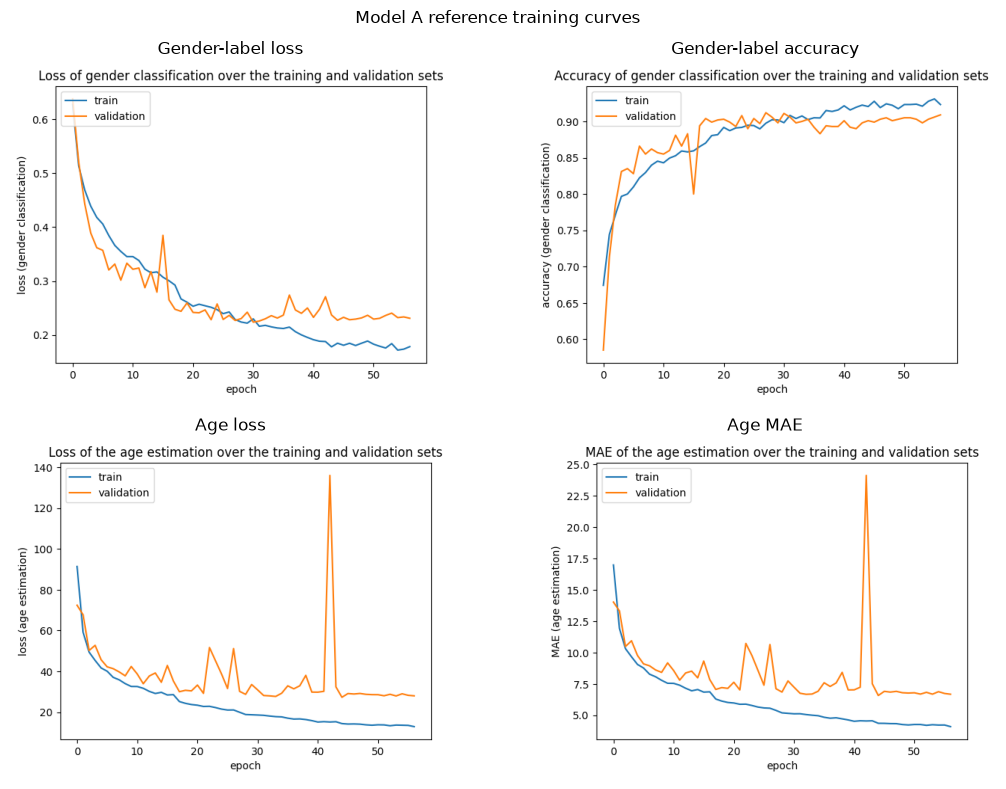

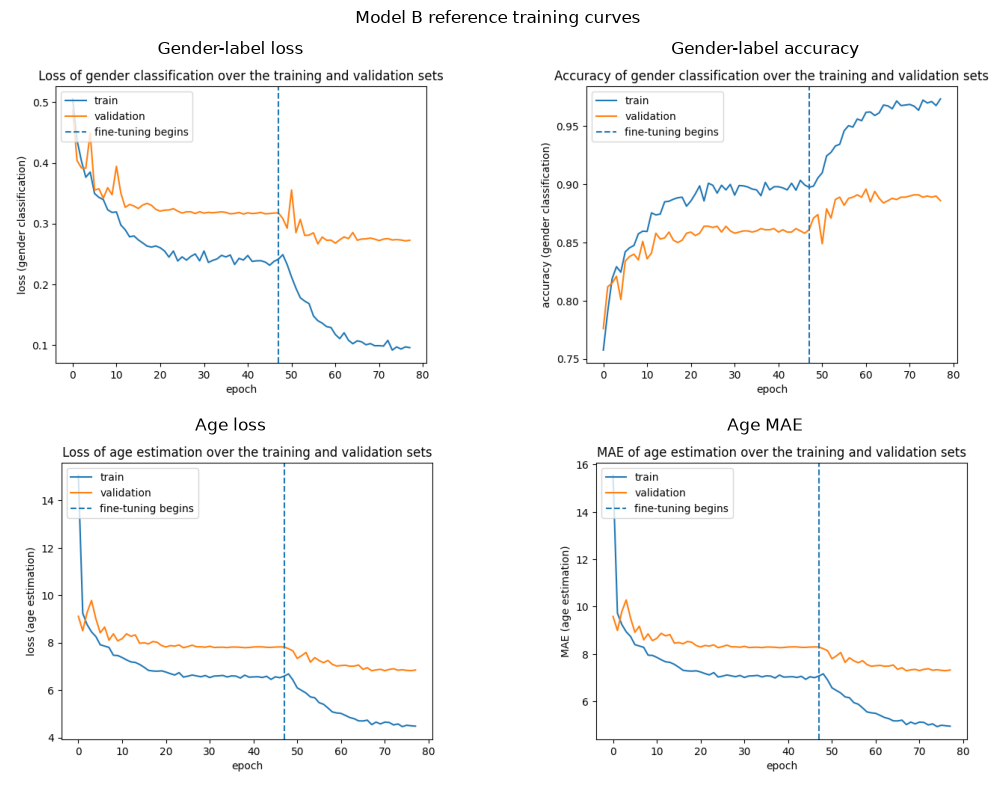

In [5]:
import json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from age_gender_cnn.plots import plot_reference_curves, plot_selected_metrics

metrics = json.loads((ROOT / "artifacts/reference/metrics.json").read_text())
selected = {key: values["selected"] for key, values in metrics.items()}
rows = [
    "| Model | Age MAE (years) | Binary gender-label accuracy | Combined loss |",
    "|---|---:|---:|---:|",
    f"| Model A — custom residual | {selected['model_a']['age_output_mae']:.4f} | {selected['model_a']['gender_output_accuracy']:.4f} | {selected['model_a']['loss']:.4f} |",
    f"| Model B — ResNet50V2 | {selected['model_b']['age_output_mae']:.4f} | {selected['model_b']['gender_output_accuracy']:.4f} | {selected['model_b']['loss']:.4f} |",
]
display(Markdown("\n".join(rows)))
curve_dir = ROOT / "artifacts/reference/training_curves"
figures = [
    plot_selected_metrics(selected),
    plot_reference_curves(curve_dir, "model_a"),
    plot_reference_curves(curve_dir, "model_b"),
]
for figure in figures:
    display(figure)
    plt.close(figure)

## Discussion

### Checkpoint selection

I selected the checkpoint with the lowest combined validation loss using `select_checkpoint` in [`training.py`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/training.py). This keeps model selection aligned with the multi-task objective rather than optimising whichever head happens to produce the most favourable individual metric. The alternative checkpoints remain useful diagnostic points because they represent different trade-offs between the two tasks.

The selected results point in the same direction. Model A's age MAE is 0.7221 years lower than Model B's (6.5747 versus 7.2968), and its binary-label accuracy is 1.2 percentage points higher (0.9010 versus 0.8890). This is a useful result because the custom model is better on both tasks, rather than trading one metric for the other.

The learning curves add context. Model A's gender accuracy rises above 0.90 and remains close to its training curve, whereas its age MAE is less smooth. That difference is expected: age is a noisier continuous target because apparent age is affected by lighting, pose, expression and individual variation. For Model B, the frozen phase already provides a workable representation. Fine-tuning improves the age and combined validation losses, but the wider gap between training and validation during this phase suggests that the extra capacity is not fully useful with only 5,000 target images.

The result does not show that transfer learning is ineffective. It suggests that, for this dataset and setup, a smaller residual model trained directly on the target tasks was a better fit than a much larger ImageNet model that could only be adapted partially. Repeated splits and subgroup-level errors would be needed before treating that pattern as a general conclusion.


## Try both models on one photograph

The interactive cell calls [`predict_photo`](https://github.com/boredjnurseman/age-gender-multitask-cnn/blob/main/src/age_gender_cnn/inference.py). It detects the largest face, or uses a square centre-crop fallback, resizes one crop to 128 × 128 and sends that same batch to both models. The side-by-side output therefore compares the models on the same visible input.

Only upload a photograph that you are permitted to use and have consent to process. Files remain in the notebook session; this project adds no storage or analytics. The sigmoid value is a **dataset-coded binary-label score**, not calibrated confidence or an identity judgement. The age output is a point estimate, and one decimal place is display formatting rather than meaningful precision.

In [ ]:
from pathlib import Path

import keras
from IPython.display import display

from age_gender_cnn.inference import download_models, predict_photo, register_upload_bytes
from age_gender_cnn.plots import plot_inference_result

LOCAL_IMAGE_PATH = None  # Example: Path("photo.jpg") outside Colab.
try:
    from google.colab import files
except ModuleNotFoundError:
    if LOCAL_IMAGE_PATH is None:
        raise RuntimeError("Set LOCAL_IMAGE_PATH or run this cell in Google Colab")
    uploaded_path = Path(LOCAL_IMAGE_PATH)
else:
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise RuntimeError("Upload exactly one photograph")
    uploaded_path = Path(next(iter(uploaded)))

cache_dir = Path(MODEL_CACHE_DIR) if MODEL_CACHE_DIR else ROOT / "models"
model_paths = download_models(cache_dir)
models = {key: keras.models.load_model(path) for key, path in model_paths.items()}
if "_SEEN_UPLOAD_DIGESTS" not in globals():
    _SEEN_UPLOAD_DIGESTS = set()
# Raises a clear error for duplicate upload bytes in this notebook session.
register_upload_bytes(uploaded_path.read_bytes(), _SEEN_UPLOAD_DIGESTS)
result = predict_photo(models, uploaded_path)
display(plot_inference_result(result))

## Optional training pipeline

The default path uses the fixed reference artifacts. Set `RUN_TRAINING_PIPELINE = True` only when you have an authorised local or mounted `train_val` directory. The package code then recreates the seeded split, trains Model A, and runs Model B's frozen and fine-tuned phases. New checkpoints go under `artifacts/local/training` by default, leaving the public reference files untouched.

In [ ]:
if RUN_TRAINING_PIPELINE:
    from pathlib import Path

    from age_gender_cnn.data import list_image_paths, load_dataset, split_paths
    from age_gender_cnn.training import train_model_a, train_model_b

    resolved_data_dir = Path(DATA_DIR) if DATA_DIR else None
    if resolved_data_dir is None:
        try:
            from google.colab import drive
        except ModuleNotFoundError as error:
            raise RuntimeError("Set DATA_DIR to an authorised train_val directory") from error
        drive.mount("/content/drive")
        resolved_data_dir = Path("/content/drive/MyDrive/train_val")
    if not resolved_data_dir.is_dir():
        raise FileNotFoundError(
            f"Authorised training directory not found: {resolved_data_dir}. Set DATA_DIR explicitly."
        )

    output_dir = Path(TRAINING_OUTPUT_DIR) if TRAINING_OUTPUT_DIR else ROOT / "artifacts/local/training"
    split = split_paths(list_image_paths(resolved_data_dir), train_fraction=0.8, seed=0)
    train_data = load_dataset(split.train)
    validation_data = load_dataset(split.validation)
    model_a, history_a = train_model_a(train_data, validation_data, output_dir / "model_a")
    model_b, history_b, fine_tune_start = train_model_b(
        train_data, validation_data, output_dir / "model_b"
    )
    print(f"Training outputs written below {output_dir}")
else:
    print("Training skipped; using saved models and reference results.")

## Limitations

- The comparison uses one 5,000-image subset and one validation split, so the size and direction of the difference may be split-sensitive.
- UTKFace age estimates and binary labels are imperfect proxies; the binary field does not represent gender identity.
- No subgroup analysis was performed, so aggregate MAE and accuracy do not show whether errors differ across age, skin tone, pose or lighting.
- Face detection, crop choice and domain shift can materially change predictions.
- The models are for education and non-consequential experimentation, not identity claims, surveillance or decisions about people.

## Next steps

Before changing either architecture, the next evaluation should report age-stratified errors and repeat the comparison across several fixed splits. That will show whether the aggregate MAE is hiding systematic errors and whether the current ranking is stable.

If the pattern holds, the next model comparison should test an ordinal-age head, such as the rank-consistent ordinal regression method proposed by Cao et al. (2020), against the current point-regression head. Any stronger augmentation should be evaluated as a separate ablation, following the approach of Zhong et al. (2017). This sequence keeps the data, architecture and evaluation questions separate, making any improvement easier to explain.

## References

- Cao, W. et al. (2020) ‘Rank consistent ordinal regression for neural networks’, *Pattern Recognition Letters*, 140, pp. 325–331.
- Caruana, R. (1997) ‘Multitask learning’, *Machine Learning*, 28, pp. 41–75.
- He, K. et al. (2016) ‘Deep residual learning for image recognition’, *Proceedings of CVPR*, pp. 770–778.
- Huber, P.J. (1964) ‘Robust estimation of a location parameter’, *Annals of Mathematical Statistics*, 35, pp. 73–101.
- Shorten, C. and Khoshgoftaar, T.M. (2019) ‘A survey on image data augmentation for deep learning’, *Journal of Big Data*, 6, 60.
- Yosinski, J. et al. (2014) ‘How transferable are features in deep neural networks?’, *Advances in Neural Information Processing Systems*, 27.
- Zhang, Z., Song, Y. and Qi, H. (2017) ‘Age progression/regression by conditional adversarial autoencoder’, *Proceedings of CVPR*, pp. 5810–5818.
- Zhong, Z. et al. (2017) ‘Random erasing data augmentation’, arXiv:1708.04896.
